#RFM Customer Segmentation

In [ ]:
#RFM analysis is used to segment customers based on their purchasing behavior.

#RFM stands for:

#Recency (R): How recently a customer made a purchase
#Frequency (F): How often a customer purchases
#Monetary (M):How much money a customer spends


#Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

##Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/Cleaned data/olist_cleaned.csv'
)

print(df.shape)
df.head()

(95809, 25)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,product_id,total_payment_value,payment_installments,payment_type,review_score,product_category_name_english,product_weight_g,product_photos_qty,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,87285b34884572647811a353c7ac498a,38.71,1.0,credit_card,4.0,housewares,500.0,4.0,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,...,595fac2a385ac33a80bd5114aec74eb8,141.46,1.0,boleto,4.0,perfumery,400.0,1.0,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,aa4383b373c6aca5d8797843e5594415,179.12,3.0,credit_card,5.0,auto,420.0,1.0,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,...,d0b61bfb1de832b15ba9d266ca96e5b0,72.20,1.0,credit_card,5.0,pet_shop,450.0,3.0,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,...,65266b2da20d04dbe00c5c2d3bb7859e,28.62,1.0,credit_card,5.0,stationery,250.0,4.0,mogi das cruzes,SP


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95809 entries, 0 to 95808
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       95809 non-null  object 
 1   customer_id                    95809 non-null  object 
 2   order_status                   95809 non-null  object 
 3   order_purchase_timestamp       95809 non-null  object 
 4   order_approved_at              95809 non-null  object 
 5   order_delivered_carrier_date   95809 non-null  object 
 6   order_delivered_customer_date  95809 non-null  object 
 7   order_estimated_delivery_date  95809 non-null  object 
 8   customer_unique_id             95809 non-null  object 
 9   customer_city                  95809 non-null  object 
 10  customer_state                 95809 non-null  object 
 11  total_items                    95809 non-null  float64
 12  total_price                    95809 non-null 

In [ ]:
# Convert Date Columns

In [ ]:
date_cols = [
    'order_purchase_timestamp'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print("Date conversion completed")

Date conversion completed


## Create Reference Date

In [ ]:
#The latest purchase date in the dataset is used as the reference point for calculating recency.

In [ ]:
reference_date = (
    df['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)

print("Reference Date:", reference_date)

Reference Date: 2018-08-30 15:00:37


## Calculate RFM Metrics

In [ ]:
rfm = df.groupby(
    'customer_unique_id'
).agg(

    Recency=(
        'order_purchase_timestamp',
        lambda x: (
            reference_date - x.max()
        ).days
    ),

    Frequency=(
        'order_id',
        'nunique'
    ),

    Monetary=(
        'total_payment_value',
        'sum'
    )

).reset_index()

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [ ]:
print(rfm.shape)
rfm.describe()

(92733, 4)


,Recency,Frequency,Monetary
count,92733.000000,92733.000000,92733.000000
mean,237.756840,1.033171,164.888539
std,152.561464,0.208415,225.005261
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.000000
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.140000
max,714.000000,15.000000,13664.080000


## RFM Score Calculation

In [ ]:
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(
        method='first'
    ),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4


In [ ]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214


## Customer Segmentation

In [ ]:
def segment_customer(row):

    if (
        row['R_score'] >= 4 and
        row['F_score'] >= 4 and
        row['M_score'] >= 4
    ):
        return 'Champions'

    elif (
        row['F_score'] >= 4 and
        row['M_score'] >= 4
    ):
        return 'Loyal Customers'

    elif row['R_score'] >= 4:
        return 'Potential Loyalists'

    elif row['R_score'] <= 2:
        return 'At Risk'

    else:
        return 'Need Attention'

In [ ]:
rfm['Segment'] = rfm.apply(
    segment_customer,
    axis=1
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,Potential Loyalists
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,Potential Loyalists
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,At Risk
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,At Risk


In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
At Risk,31009
Potential Loyalists,30780
Need Attention,15441
Loyal Customers,9050
Champions,6453


## Visualize Customer Segments

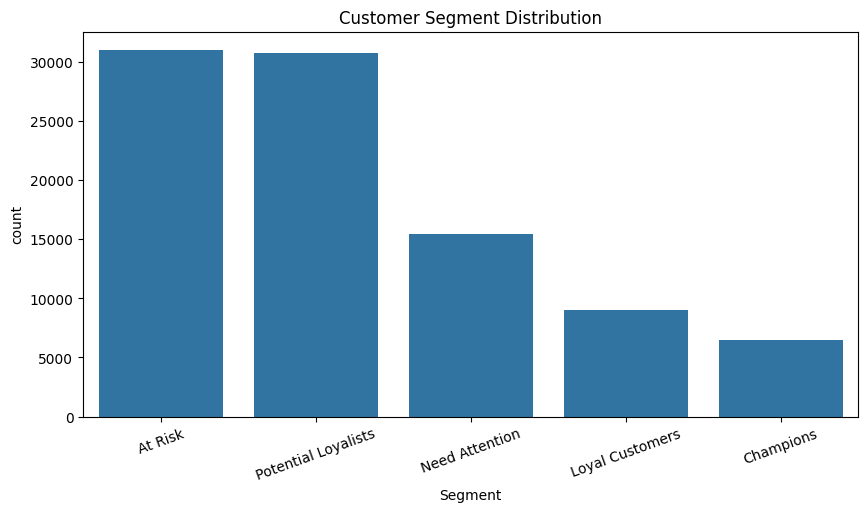

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=rfm,
    x='Segment',
    order=rfm['Segment']
    .value_counts()
    .index
)

plt.title(
    'Customer Segment Distribution'
)

plt.xticks(rotation=20)

plt.show()

In [ ]:
segment_profile = rfm.groupby(
    'Segment'
).agg({

    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'

}).round(2)

segment_profile

,Recency,Frequency,Monetary
Segment,,,
At Risk,395.16,1.01,137.09
Champions,90.97,1.18,312.41
Loyal Customers,333.79,1.15,303.08
Need Attention,220.38,1.01,129.36
Potential Loyalists,90.43,1.01,139.16


## K-Means Clustering

In [ ]:
rfm_features = rfm[
    ['Recency',
     'Frequency',
     'Monetary']
]

In [ ]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_features
)

## Elbow Method

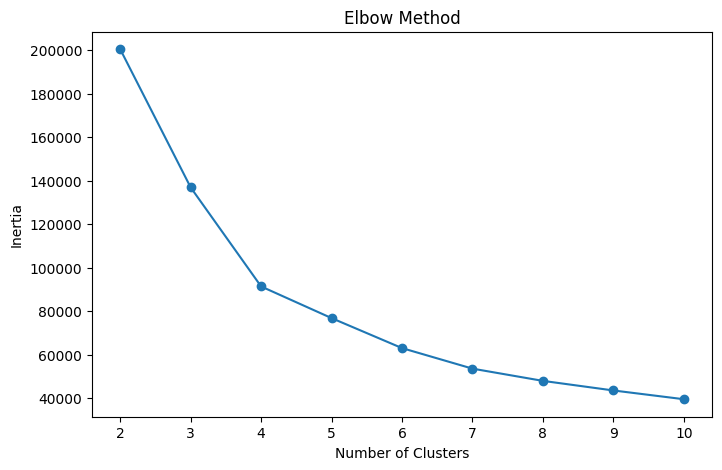

In [ ]:
inertia = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [ ]:
for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        rfm_scaled
    )

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print(
        f'K={k}: {score:.3f}'
    )

K=2: 0.739
K=3: 0.456
K=4: 0.488
K=5: 0.418
K=6: 0.436
K=7: 0.439
K=8: 0.448
K=9: 0.389
K=10: 0.394


In [ ]:
#Although K=2 had the highest silhouette score (0.739), it produced overly broad customer groups.
#K=4 was selected because it provided more interpretable and actionable customer segments
# while maintaining an acceptable silhouette score (0.488).

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,Potential Loyalists,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,Potential Loyalists,0
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,At Risk,1
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,At Risk,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,At Risk,1


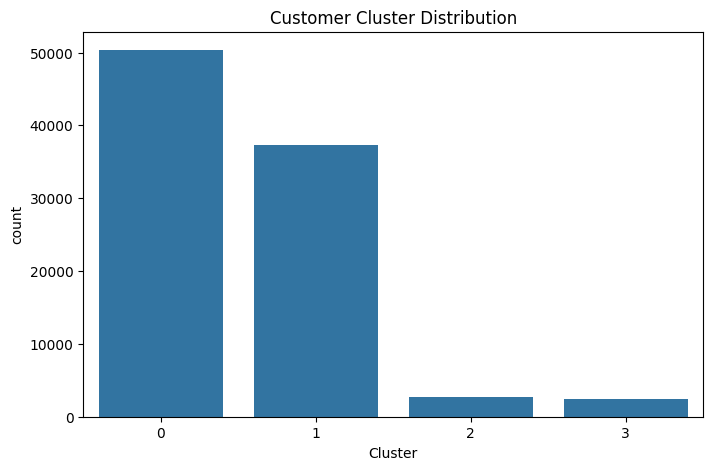

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x='Cluster'
)

plt.title(
    'Customer Cluster Distribution'
)

plt.show()

In [ ]:
cluster_profile = rfm.groupby(
    'Cluster'
)[['Recency',
   'Frequency',
   'Monetary']].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,127.99,1.00,134.17
1,387.30,1.00,133.22
2,220.57,2.11,289.00
3,238.80,1.01,1154.35


In [ ]:
# Business Insights

#- Champions are high-value customers and contribute significantly to revenue.

#- At-risk customers may require retention strategies.

#- Loyal customers can be targeted through personalized promotions.

#- Customer segmentation enables more effective marketing and resource allocation.

##Save

In [ ]:
rfm.to_csv(
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/RFM/rfm_segments.csv',
    index=False
)

print("Saved Sucessfully")

Saved Sucessfully


In [ ]:
segment_profile.to_csv(
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/RFM/segment_profile.csv'
)

cluster_profile.to_csv(
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/RFM/cluster_profile.csv'
)